# Warp-FWI on Marmousi

Entry point for the v1 Warp-FWI experiment described in `DESIGN.md`.

The notebook is a driver: every hyperparameter lives in a dataclass in
`warpfwi.config`, every piece of logic (data loading, modeling, losses, training
loops, diagnostics, plotting) lives in `src/warpfwi/`. If you want to change an
iteration count, a learning rate, or the INR architecture, edit the relevant
dataclass construction below — not the library.

## Section map

1. Imports & device.
2. Config construction (all dataclasses).
3. Data loading.
4. Observed-data generation.
5. Classical FWI baseline & plots.
6. Warp-FWI stage 1 & plots.
7. Warp-FWI stage 2 & plots.
8. Comparison panel.

## 1. Imports and device

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from dataclasses import replace
_src = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if _src not in sys.path:
    sys.path.insert(0, _src)

import torch
import matplotlib.pyplot as plt

from warpfwi.device import select_device
from warpfwi.config import (
    Config, DeviceConfig, DataConfig, AcquisitionConfig, ModelingConfig, INRConfig,
    WarpConfig, OptimConfig, OptimizerConfig, FWIPreprocessingConfig, ClassicalFWIConfig, WarpFWIConfig,
    MonotoneAnnealConfig, MonotoneModelConfig, MonotoneNTWConfig,
    MonotoneRegularizationConfig,
    GainParam,
)
from warpfwi.data import load_velocity
from warpfwi.acquisition import build_acquisition
from warpfwi.velocity import BoundedVelocity
from warpfwi.inr import build_per_shot_inrs
from warpfwi.modeling import simulate_dataset, simulate_batch
from warpfwi.preprocessing import make_boundary_taper, maybe_bandpass_dataset
from warpfwi.fwi_classical import run_classical_fwi as run_classical_fwi_loop
from warpfwi.fwi_warp import pretrain_warp, run_warp_fwi
from warpfwi.monotone import (
    build_per_shot_monotone_inrs, pretrain_monotone_warp,
    run_monotone_warp_fwi,
)
from warpfwi.monotone.model import normalized_increment_grid
from warpfwi.monotone.warp import apply_monotone_warp
from warpfwi.warp import WarpGain, normalized_rt_grid
from warpfwi.diagnostics import snr_db, ssim
from warpfwi.plotting import (
    plot_velocity, plot_velocity_panel, plot_velocity_panels,
    plot_shot_gather, plot_shot_triplet, plot_stage1_shot_comparison,
    plot_warp_field, plot_loss_curves,
)

In [2]:
def resolve_device(device="auto", gpu_index=None):
    if device == "auto":
        if torch.cuda.is_available():
            if gpu_index is None:
                gpu_index = torch.cuda.current_device()
            return torch.device(f"cuda:{gpu_index}")
        return torch.device("cpu")

    device = torch.device(device)

    if device.type == "cuda" and device.index is None:
        if gpu_index is None:
            gpu_index = torch.cuda.current_device()
        return torch.device(f"cuda:{gpu_index}")

    return device

device = resolve_device("auto", gpu_index=0)  # or 1

print('device:', device)

device: cuda:0


In [3]:
import sys
print(sys.executable)

/opt/conda/envs/deepwave/bin/python


## 2. Config

Every knob lives here. The top of each subsequent section points back to the
relevant subconfig. Iteration counts and the INR architecture are the knobs most
likely to be changed; see `SKILL.md` §Notebook conventions.

In [7]:

# Clean control panel. Reusable logic stays in src/warpfwi/; this cell only
# chooses scalar parameters and assembles dataclasses.

# Acquisition
n_shots = 35
n_receivers = 110
source_spacing_m = 150.0
receiver_spacing_m = 50.0
source_start_m = 500.0
receiver_start_m = 250.0
source_depth_m = 20.0
receiver_depth_m = 20.0
geometry_mode = "fixed_spread"  # "fixed_spread", "moving_spread", "split_spread"
allow_partial_spread = False
x_rounding_mode = "round"
f_peak = 10.0

# Model
marmousi_path = None        # leave None -> synthetic fallback
crop_origin_x = 0
crop_origin_z = 0
crop_nx = None
crop_nz = None
synthetic_shape = (200, 600)  # nz, nx
smoothing_sigma = 160.0
v_min = 1500.0
v_max = 5000.0

# Modeling
modeling_dx = 10.0
modeling_dz = 10.0
modeling_dt = 0.004
modeling_nt = 750
pml_width = 50
pml_freq = 5.5
accuracy = 4

# Classical FWI
run_classical_fwi = True
classical_optimizer_name = "adam"  # "adam" or "lbfgs"
classical_n_iter = 35
classical_adam_lr = 0.08
classical_lbfgs_lr = 1.0
classical_lbfgs_max_iter = 1
classical_lbfgs_history_size = 10
classical_lbfgs_line_search_fn = "strong_wolfe"
classical_batch_size = 8
classical_gradient_clip = 1.0

# WarpFWI
run_warpfwi = True
warpfwi_velocity_optimizer = "adam"  # "adam" or experimental "lbfgs_velocity_only"
warpfwi_theta_optimizer = "adam"
warpfwi_stage1_iter = 150
warpfwi_stage2_iter = 75
warpfwi_lr_v = 0.08
warpfwi_lr_theta = 1e-3
warpfwi_batch_size = 4
warpfwi_gradient_clip = 1.0

# Preprocessing shared by classical FWI and WarpFWI
gradient_taper_enabled = False
gradient_taper_width_cells = 20
gradient_taper_type = "hann"   # "cosine" or "hann"
bandpass_enabled = True
bandpass_fmin_hz = 4.0
bandpass_fmax_hz = 7.0
bandpass_order = 4

fwi_preprocess = FWIPreprocessingConfig(
    gradient_taper_enabled=gradient_taper_enabled,
    gradient_taper_width_cells=gradient_taper_width_cells,
    gradient_taper_type=gradient_taper_type,
    bandpass_enabled=bandpass_enabled,
    bandpass_fmin_hz=bandpass_fmin_hz,
    bandpass_fmax_hz=bandpass_fmax_hz,
    bandpass_order=bandpass_order,
    filter_source_wavelet_for_fwi_band=True,
)

modeling_cfg = ModelingConfig(
    dx=modeling_dx,
    dz=modeling_dz,
    dt=modeling_dt,
    pml_width=pml_width,
    pml_freq=pml_freq,
    accuracy=accuracy,
)

classical_optimizer = OptimizerConfig(
    name=classical_optimizer_name,
    lr=classical_adam_lr if classical_optimizer_name == "adam" else classical_lbfgs_lr,
    max_iter=classical_lbfgs_max_iter,
    history_size=classical_lbfgs_history_size,
    line_search_fn=classical_lbfgs_line_search_fn,
    gradient_clip=classical_gradient_clip,
    use_full_batch_for_lbfgs=True,
    log_closure_evals=True,
)

cfg = Config(
    device=DeviceConfig(prefer='auto'),
    data=DataConfig(
        marmousi_path=marmousi_path,
        synthetic_shape=synthetic_shape,
        crop_origin_x=crop_origin_x,
        crop_origin_z=crop_origin_z,
        crop_nx=crop_nx,
        crop_nz=crop_nz,
        dx=modeling_dx,
        dz=modeling_dz,
        smooth_sigma=smoothing_sigma,
        v_min=v_min,
        v_max=v_max,
    ),
    acquisition=AcquisitionConfig(
        n_shots=n_shots,
        n_receivers=n_receivers,
        f_peak=f_peak,
        dt=modeling_dt,
        nt=modeling_nt,
        source_spacing_m=source_spacing_m,
        receiver_spacing_m=receiver_spacing_m,
        source_start_m=source_start_m,
        receiver_start_m=receiver_start_m,
        source_depth_m=source_depth_m,
        receiver_depth_m=receiver_depth_m,
        geometry_mode=geometry_mode,
        allow_partial_spread=allow_partial_spread,
        x_rounding_mode=x_rounding_mode,
    ),
    modeling=modeling_cfg,
    inr=INRConfig(
        depth=4, width=128, activation='gelu', n_fourier_bands=12, omega_max=24.0,
        gain_param=GainParam.NONE,
    ),
    warp=WarpConfig(
        T_max_periods=20.0,
        alpha_smooth=1000.0, beta_gain=20.0, offset_smooth=True,
        lambda_0=1.0, lambda_final=20.0, schedule='geometric',
    ),
    classical=ClassicalFWIConfig(
        n_iter=classical_n_iter,
        optim=OptimConfig(
            name=classical_optimizer_name,
            lr_v=classical_adam_lr,
            batch_size=classical_batch_size,
            grad_clip=classical_gradient_clip,
        ),
        optimizer=classical_optimizer,
        modeling=replace(modeling_cfg),
        preprocess=replace(fwi_preprocess),
        seed=0,
    ),
    warpfwi=WarpFWIConfig(
        stage1_iter=warpfwi_stage1_iter,
        stage2_iter=warpfwi_stage2_iter,
        lambda_pre=0.1,
        optim=OptimConfig(
            lr_v=warpfwi_lr_v,
            lr_theta=warpfwi_lr_theta,
            batch_size=warpfwi_batch_size,
            grad_clip=warpfwi_gradient_clip,
        ),
        velocity_optimizer=warpfwi_velocity_optimizer,
        theta_optimizer=warpfwi_theta_optimizer,
        modeling=replace(modeling_cfg),
        preprocess=replace(fwi_preprocess),
        seed=0,
    ),
    monotone_ntw=MonotoneNTWConfig(
        stage1_iter=150,
        stage2_iter=50,
        run_stage2=True,
        anneal=MonotoneAnnealConfig(
            enabled=True, schedule='geometric', f_min=2.0, f_max=10.0, order=8.0,
        ),
        model=MonotoneModelConfig(
            depth=4, width=128, activation='gelu', n_fourier_bands=12, omega_max=24.0,
        ),
        reg=MonotoneRegularizationConfig(
            identity=1.0, time_smooth=10.0, receiver_smooth=1.0,
            lambda_0=0.1, lambda_final=1.0, schedule='geometric',
        ),
        optim=OptimConfig(lr_v=0.08, lr_theta=1e-3, batch_size=4, grad_clip=1.0),
        seed=0,
    ),
)

shot_plot_idx = min(10, cfg.acquisition.n_shots - 1)
gather_shared_clim = True
gather_robust_pct = 99.0
velocity_shared_colorbar = True
T_max = cfg.warp.T_max_periods / cfg.acquisition.f_peak

print("Acquisition controls:")
print(f"  mode={cfg.acquisition.geometry_mode}, shots={cfg.acquisition.n_shots}, receivers={cfg.acquisition.n_receivers}")
print(f"  source start/spacing={source_start_m} / {source_spacing_m} m")
print(f"  receiver start/spacing={receiver_start_m} / {receiver_spacing_m} m")
print("Modeling controls:")
print(f"  dx={cfg.modeling.dx} dz={cfg.modeling.dz} dt={cfg.modeling.dt} nt={cfg.acquisition.nt}")
print(f"  pml_width={cfg.modeling.pml_width} pml_freq={cfg.modeling.pml_freq} accuracy={cfg.modeling.accuracy}")
print("Classical FWI optimizer:", cfg.classical.optimizer)
print("WarpFWI optimizers:", cfg.warpfwi.velocity_optimizer, cfg.warpfwi.theta_optimizer)
print("FWI preprocessing:", cfg.classical.preprocess)
assert cfg.classical.preprocess == cfg.warpfwi.preprocess

warpfwi_loss_configs = {
    'original_l2': replace(
        cfg.warpfwi,
        stage1_misfit='l2',
        stage2_theta_misfit='l2',
        stage2_v_misfit='l2',
        stage2_routing='auto',
    ),
    'hybrid_envelope_theta_l2_v': replace(
        cfg.warpfwi,
        stage1_misfit='envelope_l2',
        stage2_theta_misfit='envelope_l2',
        stage2_v_misfit='l2',
        stage2_routing='auto',
        envelope_eps=1e-8,
    ),
}

active_warpfwi_loss = 'hybrid_envelope_theta_l2_v'
cfg.warpfwi = warpfwi_loss_configs[active_warpfwi_loss]
print(f'T_max = {T_max:.4f} s')
print('active Warp-FWI loss preset:', active_warpfwi_loss, cfg.warpfwi)


Acquisition controls:
  mode=fixed_spread, shots=35, receivers=110
  source start/spacing=500.0 / 150.0 m
  receiver start/spacing=250.0 / 50.0 m
Modeling controls:
  dx=10.0 dz=10.0 dt=0.004 nt=750
  pml_width=50 pml_freq=5.5 accuracy=4
Classical FWI optimizer: OptimizerConfig(name='adam', lr=0.08, max_iter=1, history_size=10, line_search_fn='strong_wolfe', tolerance_grad=1e-07, tolerance_change=1e-09, max_eval=None, gradient_clip=1.0, use_full_batch_for_lbfgs=True, log_closure_evals=True)
WarpFWI optimizers: adam adam
FWI preprocessing: FWIPreprocessingConfig(gradient_taper_enabled=False, gradient_taper_width_cells=20, gradient_taper_type='hann', bandpass_enabled=True, bandpass_fmin_hz=4.0, bandpass_fmax_hz=7.0, bandpass_order=4, filter_source_wavelet_for_fwi_band=True)
T_max = 2.0000 s
active Warp-FWI loss preset: hybrid_envelope_theta_l2_v WarpFWIConfig(stage1_iter=150, stage2_iter=75, lambda_pre=0.1, stage1_misfit='envelope_l2', stage2_theta_misfit='envelope_l2', stage2_v_misfit='

In [8]:
# Count INR parameters
def count_trainable_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

# If you already built the per-shot INR dictionary/list
n_per_shot = count_trainable_params(next(iter(inrs.values())))
n_shots = len(inrs)
n_total = sum(count_trainable_params(m) for m in inrs.values())

print(f"Trainable INR parameters per shot: {n_per_shot:,}")
print(f"Number of shot INRs: {n_shots}")
print(f"Total trainable INR parameters: {n_total:,}")

NameError: name 'inrs' is not defined

## 3. Data & acquisition

Marmousi file not found at None; falling back to synthetic layered model with shape (200, 600).
v_true shape: (200, 600)
resolved acquisition:
  n_shots: 35  n_receivers: 110  nt: 750
  Deepwave location order: [iz, ix]
  physical coordinate order: [x_m, z_m]
  source x range (m): 500.0 5600.0
  receiver x range (m): 250.0 5700.0


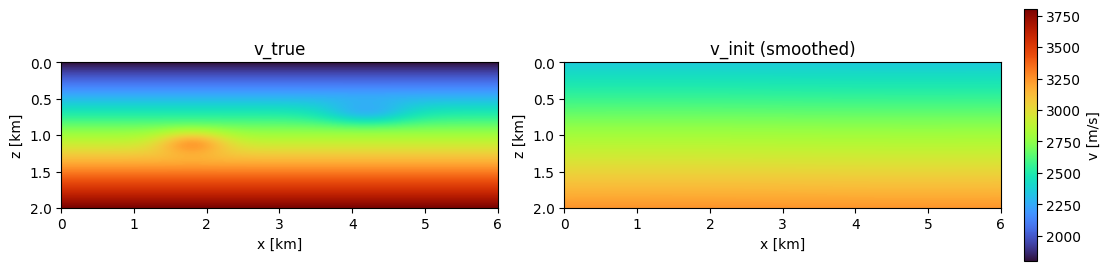

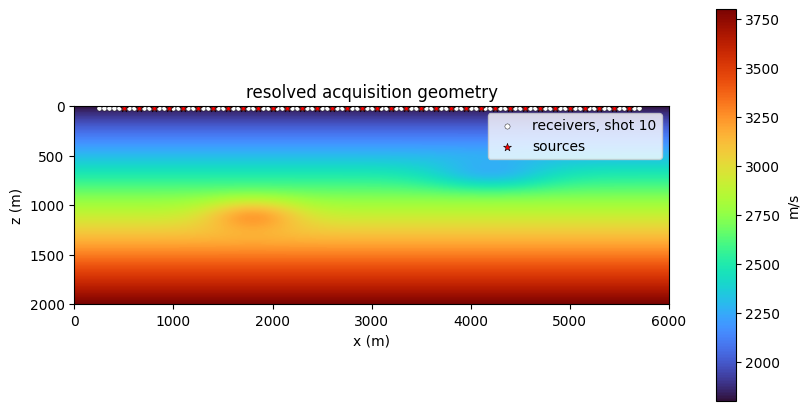

In [9]:

v_true, v_init = load_velocity(cfg.data, device=device, log=print)
print('v_true shape:', tuple(v_true.shape))
acq = build_acquisition(cfg.acquisition, cfg.data, v_true.shape, device=device)
print('resolved acquisition:')
print('  n_shots:', acq.n_shots, ' n_receivers:', acq.n_receivers, ' nt:', acq.nt)
print('  Deepwave location order:', acq.metadata['index_order'])
print('  physical coordinate order:', acq.metadata['physical_order'])
print('  source x range (m):', float(acq.source_locations_m[..., 0].min()), float(acq.source_locations_m[..., 0].max()))
print('  receiver x range (m):', float(acq.receiver_locations_m[..., 0].min()), float(acq.receiver_locations_m[..., 0].max()))

vmin, vmax = float(v_true.min()), float(v_true.max())
fig = plot_velocity_panels(
    [v_true, v_init],
    ['v_true', 'v_init (smoothed)'],
    dx=cfg.data.dx,
    vmin=vmin,
    vmax=vmax,
    shared_colorbar=velocity_shared_colorbar,
)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
im = ax.imshow(v_true.detach().cpu(), cmap='turbo', extent=[0, v_true.shape[1]*cfg.data.dx, v_true.shape[0]*cfg.data.dz, 0], vmin=vmin, vmax=vmax)
src_xy = acq.source_locations_m[:, 0].detach().cpu()
rec_xy = acq.receiver_locations_m[shot_plot_idx].detach().cpu()
ax.scatter(rec_xy[:, 0], rec_xy[:, 1], s=14, c='white', edgecolors='black', linewidths=0.3, label=f'receivers, shot {shot_plot_idx}')
ax.scatter(src_xy[:, 0], src_xy[:, 1], s=36, marker='*', c='red', edgecolors='black', linewidths=0.4, label='sources')
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title('resolved acquisition geometry')
ax.legend(loc='upper right')
fig.colorbar(im, ax=ax, label='m/s')
plt.show()


In [10]:
# Sanity checks for notebook-controlled FWI preprocessing.
if cfg.classical.preprocess.gradient_taper_enabled:
    taper_mask = make_boundary_taper(
        tuple(v_init.shape),
        cfg.classical.preprocess.gradient_taper_width_cells,
        cfg.classical.preprocess.gradient_taper_type,
        device=device,
        dtype=v_init.dtype,
    )
    print("Gradient taper mask:")
    print(f"  shape: {tuple(taper_mask.shape)}")
    print(f"  min/max: {float(taper_mask.min()):.3f} / {float(taper_mask.max()):.3f}")
    fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)
    im = ax.imshow(taper_mask.detach().cpu(), cmap="viridis", vmin=0.0, vmax=1.0)
    ax.set_title("velocity-gradient boundary taper")
    ax.set_xlabel("x cell")
    ax.set_ylabel("z cell")
    fig.colorbar(im, ax=ax, label="gradient multiplier")
    plt.show()
else:
    print("Gradient taper disabled.")

print("Bandpass sanity check will run after observed data generation.")


Gradient taper disabled.
Bandpass sanity check will run after observed data generation.


## 4. Observed data

d_obs shape: (35, 110, 750)
Bandpass preview:
  raw observed shape: (35, 110, 750)
  filtered preview shape: (35, 110, 750)
  frequency band: 4.0 - 7.0 Hz


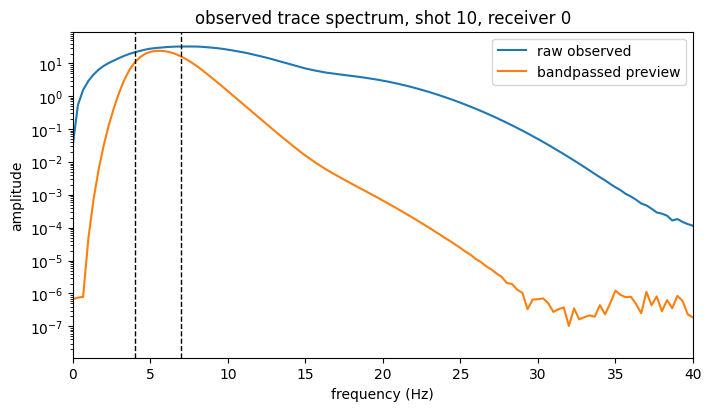

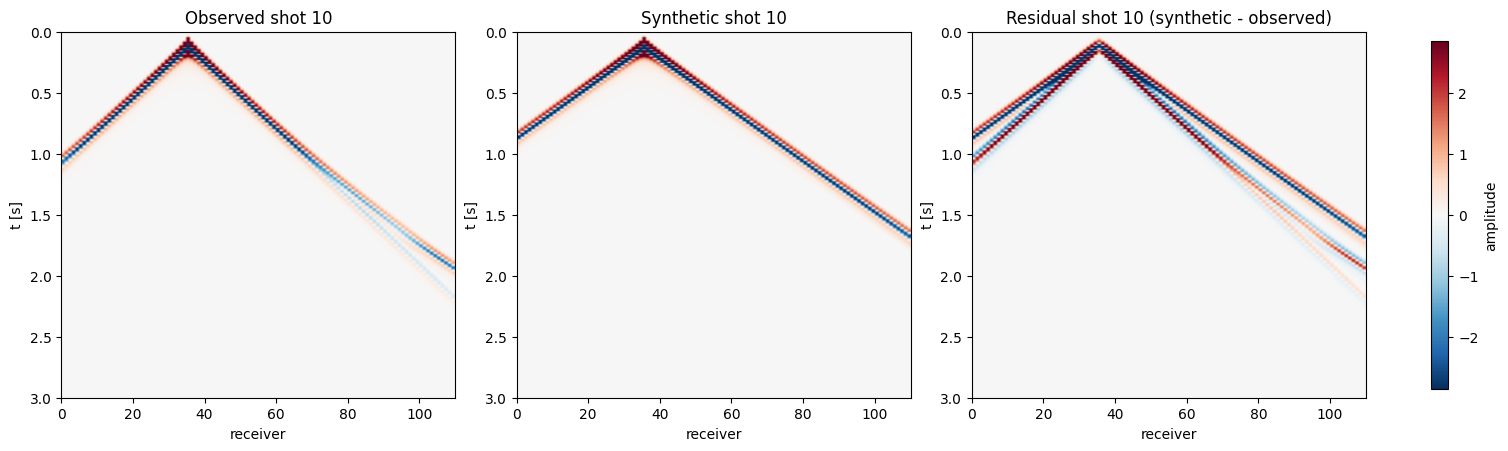

In [11]:
d_obs = simulate_dataset(v_true, acq, cfg.modeling, device=v_true.device, batch_size=cfg.classical.optim.batch_size)
print('d_obs shape:', tuple(d_obs.shape))

with torch.no_grad():
    shot_idx_t = torch.tensor([shot_plot_idx], device=device)
    d_syn_init = simulate_batch(v_init, acq, shot_idx_t, cfg.modeling, device=v_init.device)[0]

if cfg.classical.preprocess.bandpass_enabled:
    d_obs_filtered_preview = maybe_bandpass_dataset(d_obs, acq.dt, cfg.classical.preprocess)
    trace_raw = d_obs[shot_plot_idx, 0].detach().cpu()
    trace_filt = d_obs_filtered_preview[shot_plot_idx, 0].detach().cpu()
    freqs = torch.fft.rfftfreq(acq.nt, d=acq.dt)
    amp_raw = torch.fft.rfft(trace_raw).abs()
    amp_filt = torch.fft.rfft(trace_filt).abs()

    print("Bandpass preview:")
    print(f"  raw observed shape: {tuple(d_obs.shape)}")
    print(f"  filtered preview shape: {tuple(d_obs_filtered_preview.shape)}")
    print(
        f"  frequency band: {cfg.classical.preprocess.bandpass_fmin_hz} - "
        f"{cfg.classical.preprocess.bandpass_fmax_hz} Hz"
    )
    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    ax.semilogy(freqs, amp_raw + 1e-12, label="raw observed")
    ax.semilogy(freqs, amp_filt + 1e-12, label="bandpassed preview")
    ax.axvline(cfg.classical.preprocess.bandpass_fmin_hz, color="k", linestyle="--", linewidth=1)
    ax.axvline(cfg.classical.preprocess.bandpass_fmax_hz, color="k", linestyle="--", linewidth=1)
    ax.set_xlim(0.0, min(40.0, 0.5 / acq.dt))
    ax.set_xlabel("frequency (Hz)")
    ax.set_ylabel("amplitude")
    ax.set_title(f"observed trace spectrum, shot {shot_plot_idx}, receiver 0")
    ax.legend()
    plt.show()
else:
    print("Bandpass disabled; observed data are passed raw and backend filtering is skipped.")

fig = plot_shot_triplet(
    d_obs[shot_plot_idx],
    d_syn_init,
    dt=acq.dt,
    shot_idx=shot_plot_idx,
    shared_clim=gather_shared_clim,
    robust_pct=gather_robust_pct,
)
plt.show()


## 5. Classical FWI baseline

Iteration count: `cfg.classical.n_iter`. Optimizer: `cfg.classical.optimizer.name` (`"adam"` or `"lbfgs"`).


[classical:preprocess] bandpass enabled f=[4, 7] Hz order=4; time_axis=-1
[classical:preprocess] filtering mode: observed receiver data filtered=True  source wavelet filtered before propagation=True  synthetic receiver data filtered after propagation=False
[classical:init] optimizer=adam lr=0.08  v_init=[2356.7, 3243.9]  near_bounds=(0.000, 0.000)  exact_bounds=(0.000, 0.000)  phi0=[-1.13, -0.01]  |phi0|>(20,40,60)=(0.000, 0.000, 0.000)  recon_err(max,mean)=(2.441e-04, 4.360e-05)
[classical:first-batch:pre-step]  phi=[-1.13, -0.01]  v=[2356.7, 3243.9]  near_bounds=(0.000, 0.000)  |grad|=2.746e-03
[classical:first-batch:post-step]  phi=[-1.21, 0.05]  v=[2306.0, 3297.0]  near_bounds=(0.000, 0.000)
[classical] iter 1/35  loss=4.2340e-02  resid=2.058e-01  |grad|=1.212e-03  phi=[-1.51, 0.09]  v=[2132.5, 3325.2]  near_bounds=(0.000, 0.000)
[classical] iter 2/35  loss=3.3864e-02  resid=1.840e-01  |grad|=9.500e-04  phi=[-1.86, 0.11]  v=[1970.4, 3349.4]  near_bounds=(0.000, 0.000)
[classical] i

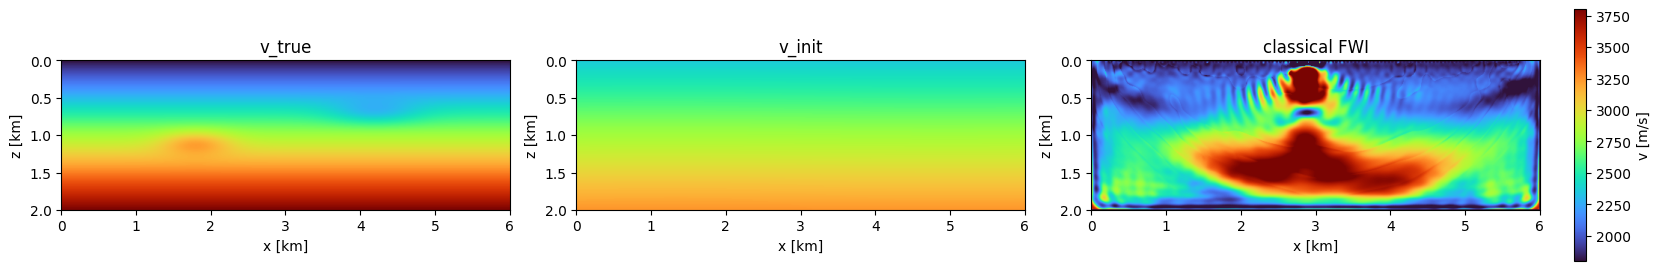

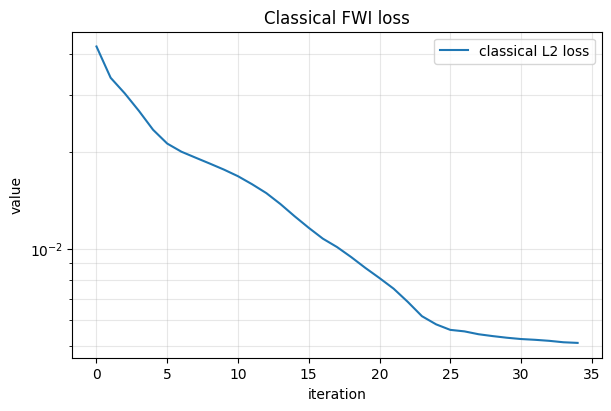

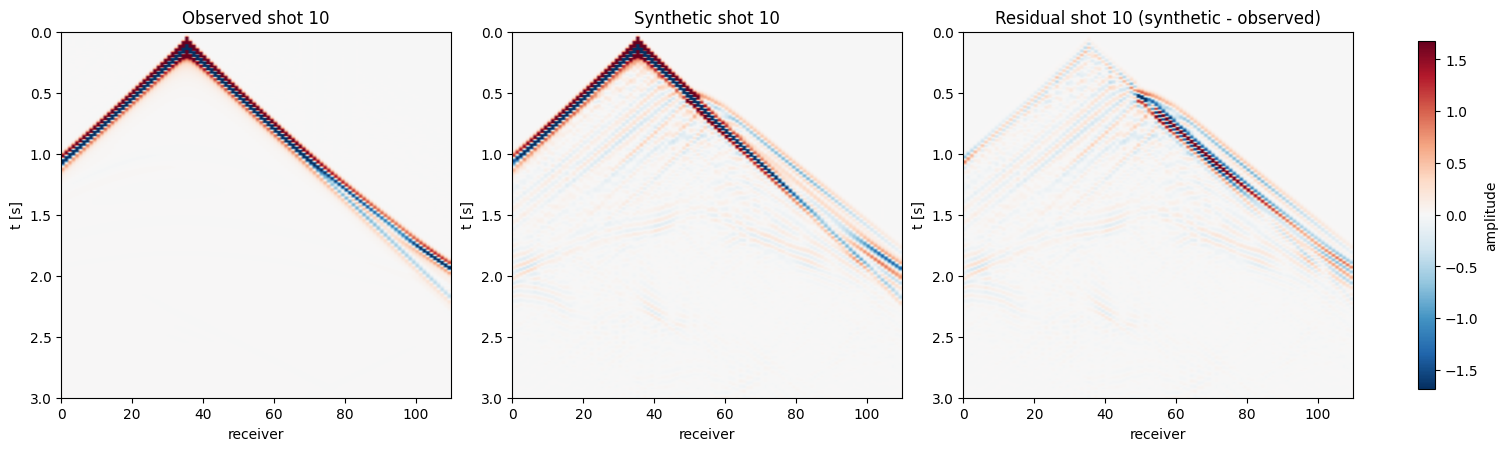

In [12]:
vp_classical = BoundedVelocity.from_velocity(v_init, cfg.data.v_min, cfg.data.v_max).to(device)
log_c = run_classical_fwi_loop(vp_classical, acq, d_obs, cfg.classical, device=device, log=print)
v_c = vp_classical.v().detach()
print(f'classical: SNR={snr_db(v_c, v_true):.2f} dB, SSIM={ssim(v_c, v_true):.3f}')

fig = plot_velocity_panels(
    [v_true, v_init, v_c],
    ['v_true', 'v_init', 'classical FWI'],
    dx=cfg.data.dx,
    vmin=vmin,
    vmax=vmax,
    shared_colorbar=velocity_shared_colorbar,
)
plt.show()

fig = plot_loss_curves({'classical L2 loss': log_c['loss']}, title='Classical FWI loss')
plt.show()

d_syn_classical = simulate_batch(v_c, acq, shot_idx_t, cfg.modeling, device=device)[0]

fig = plot_shot_triplet(
    d_obs[shot_plot_idx],
    d_syn_classical,
    dt=acq.dt,
    shot_idx=shot_plot_idx,
    shared_clim=gather_shared_clim,
    robust_pct=gather_robust_pct,
)
plt.show()

## 6. Warp-FWI stage 1 (warp pretraining)

Iteration count per shot: `cfg.warpfwi.stage1_iter`. Holds `v = v_init` fixed
and fits each per-shot INR so that `W_θ[d_syn(v_init)] ≈ d_obs`.

[stage1:preprocess] bandpass enabled f=[4, 7] Hz order=4; time_axis=-1
[stage1:preprocess] filtering mode: observed receiver data filtered=True  source wavelet filtered before propagation=True  synthetic receiver data filtered after propagation=False
[stage1] pretraining all 35 shots; misfit=envelope_l2; logging every 3 shot(s)
[stage1] shot 3/35  loss[0]=2.325e-02  loss[-1]=7.002e-03
[stage1] shot 6/35  loss[0]=2.408e-02  loss[-1]=6.788e-03
[stage1] shot 9/35  loss[0]=2.509e-02  loss[-1]=6.492e-03
[stage1] shot 12/35  loss[0]=2.606e-02  loss[-1]=5.861e-03
[stage1] shot 15/35  loss[0]=2.583e-02  loss[-1]=4.728e-03
[stage1] shot 18/35  loss[0]=2.565e-02  loss[-1]=4.559e-03
[stage1] shot 21/35  loss[0]=2.602e-02  loss[-1]=5.169e-03
[stage1] shot 24/35  loss[0]=2.559e-02  loss[-1]=5.914e-03
[stage1] shot 27/35  loss[0]=2.422e-02  loss[-1]=6.789e-03
[stage1] shot 30/35  loss[0]=2.338e-02  loss[-1]=7.055e-03
[stage1] shot 33/35  loss[0]=2.321e-02  loss[-1]=7.210e-03
[stage1] shot 35/35  los

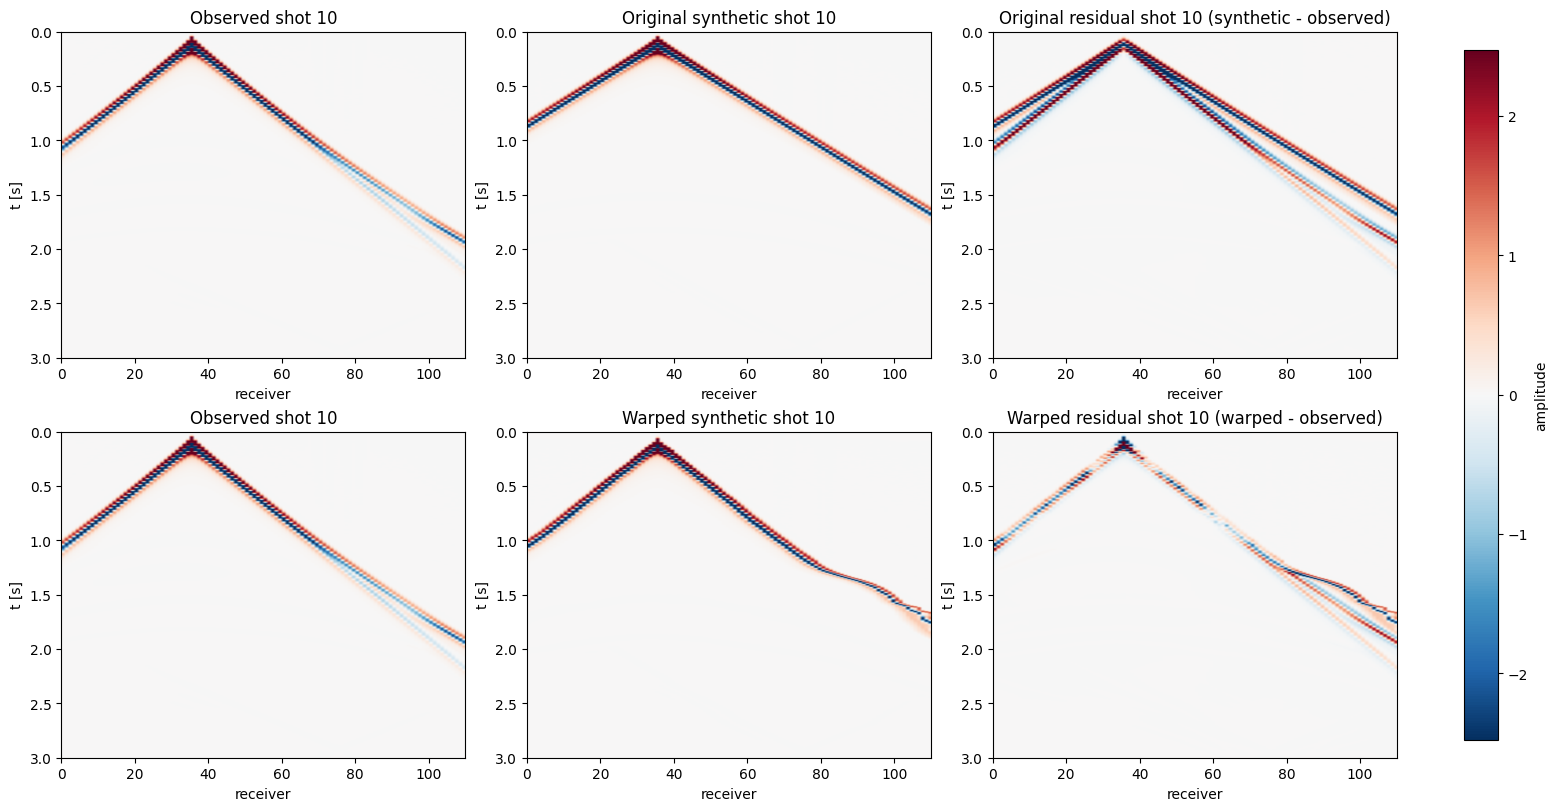

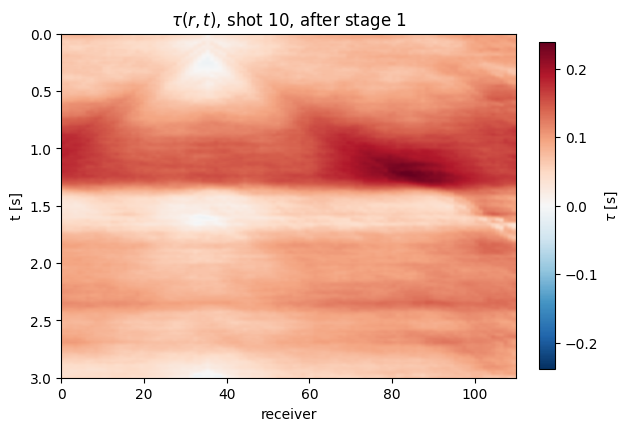

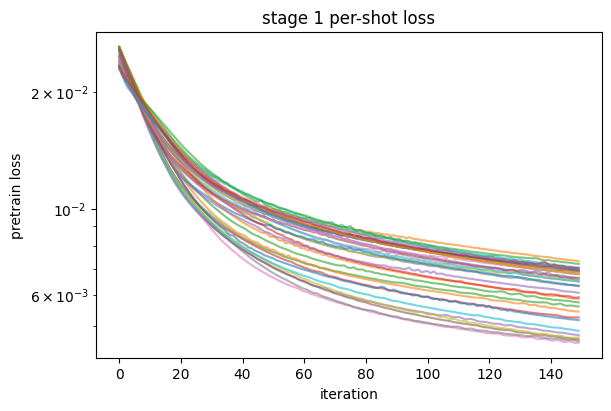

In [13]:
vp_warp = BoundedVelocity.from_velocity(v_init, cfg.data.v_min, cfg.data.v_max).to(device)
inrs = build_per_shot_inrs(acq.n_shots, cfg.inr, device=device)

log_s1 = pretrain_warp(
    vp_warp, inrs, acq, d_obs, cfg.warpfwi,
    warp_cfg_T_max=T_max,
    warp_cfg_alpha=cfg.warp.alpha_smooth,
    warp_cfg_beta=cfg.warp.beta_gain,
    warp_cfg_offset_smooth=cfg.warp.offset_smooth,
    device=device, log=print,
)

grid_rt = normalized_rt_grid(acq.n_receivers, acq.nt, device=device)
with torch.no_grad():
    shot_idx_t = torch.tensor([shot_plot_idx], device=device)
    syn_stage1 = simulate_batch(vp_warp.v(), acq, shot_idx_t, cfg.modeling, device=device)[0]
    wg = WarpGain(inrs[shot_plot_idx], T_max=T_max)
    warped_stage1, tau_stage1, gain_raw_stage1 = wg(syn_stage1, grid_rt, dt=acq.dt)

fig = plot_stage1_shot_comparison(
    d_obs[shot_plot_idx],
    syn_stage1,
    warped_stage1,
    dt=acq.dt,
    shot_idx=shot_plot_idx,
    shared_clim=gather_shared_clim,
    robust_pct=gather_robust_pct,
)
plt.show()

fig = plot_warp_field(
    tau_stage1,
    dt=acq.dt,
    title=rf'$\tau(r, t)$, shot {shot_plot_idx}, after stage 1',
)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
for i, losses in enumerate(log_s1['loss_per_shot']):
    ax.semilogy(losses, alpha=0.6, label=f'shot {i}' if acq.n_shots <= 8 else None)
ax.set_xlabel('iteration')
ax.set_ylabel('pretrain loss')
ax.set_title('stage 1 per-shot loss')
if acq.n_shots <= 8:
    ax.legend(ncol=2, fontsize=8)
plt.show()


## 7. Warp-FWI stage 2 (joint)

Iteration count: `cfg.warpfwi.stage2_iter`. Default velocity/theta optimizer is Adam. The experimental `"lbfgs_velocity_only"` velocity optimizer is intentionally velocity-only and currently raises a clear `NotImplementedError` until that path is completed.


[stage2:preprocess] bandpass enabled f=[4, 7] Hz order=4; time_axis=-1
[stage2:preprocess] filtering mode: observed receiver data filtered=True  source wavelet filtered before propagation=True  synthetic receiver data filtered after propagation=False
[stage2] routing=dual  theta_misfit=envelope_l2  v_misfit=l2
[stage2] iter 1/75  lam=1.000  loss=3.949e-02  data=1.825e-02  reg=2.124e-02  |tau|/Tmax=0.129  phi=[-1.78, 0.11]  v=[2007.0, 3349.6]  near_bounds=(0.000, 0.000)
[stage2] iter 2/75  lam=1.041  loss=5.216e-02  data=3.254e-02  reg=1.884e-02  |tau|/Tmax=0.100  phi=[-2.41, 0.17]  v=[1788.1, 3401.5]  near_bounds=(0.000, 0.000)
[stage2] iter 3/75  lam=1.084  loss=3.699e-02  data=2.352e-02  reg=1.242e-02  |tau|/Tmax=0.088  phi=[-2.90, 0.24]  v=[1681.8, 3461.0]  near_bounds=(0.000, 0.000)
[stage2] iter 4/75  lam=1.129  loss=2.948e-02  data=1.819e-02  reg=1.000e-02  |tau|/Tmax=0.078  phi=[-3.32, 0.30]  v=[1622.3, 3511.1]  near_bounds=(0.000, 0.000)
[stage2] iter 5/75  lam=1.176  loss=2.44

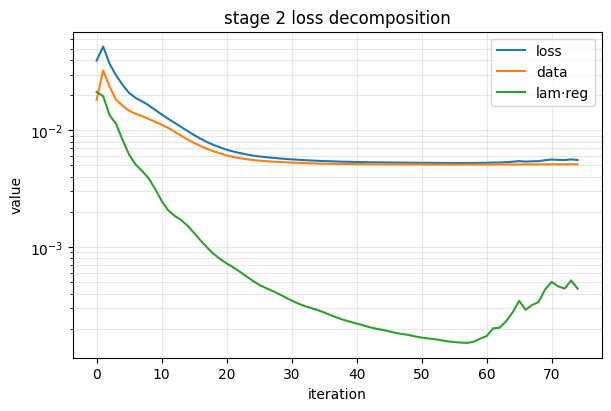

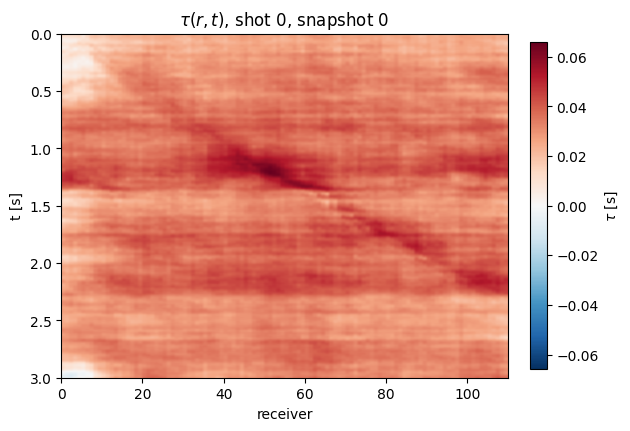

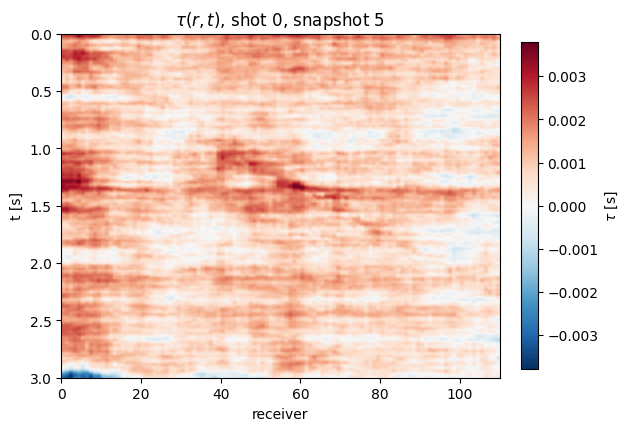

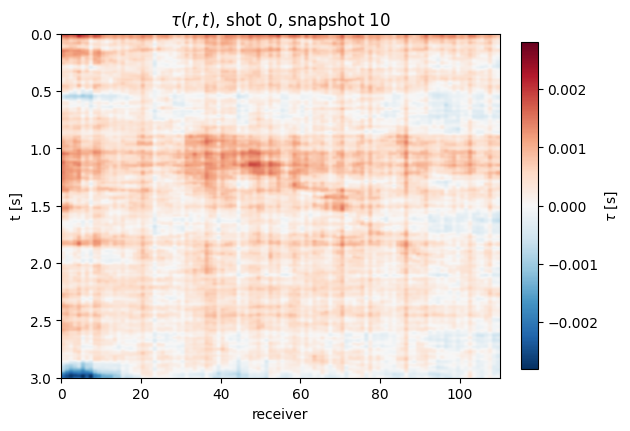

In [14]:
log_s2 = run_warp_fwi(
    vp_warp, inrs, acq, d_obs, cfg.warpfwi,
    warp_cfg_T_max=T_max,
    warp_cfg_alpha=cfg.warp.alpha_smooth,
    warp_cfg_beta=cfg.warp.beta_gain,
    warp_cfg_offset_smooth=cfg.warp.offset_smooth,
    warp_cfg_lambda_0=cfg.warp.lambda_0,
    warp_cfg_lambda_final=cfg.warp.lambda_final,
    warp_cfg_schedule=cfg.warp.schedule,
    device=device, log=print,
)

v_w = vp_warp.v().detach()
print('Warp-FWI routing:', log_s2['stage2_routing_mode'])
print('Warp-FWI misfits:', log_s2['stage2_theta_misfit_name'], log_s2['stage2_v_misfit_name'])
print(f'Warp-FWI: SNR={snr_db(v_w, v_true):.2f} dB, SSIM={ssim(v_w, v_true):.3f}')
print(f'Classical: SNR={snr_db(v_c, v_true):.2f} dB, SSIM={ssim(v_c, v_true):.3f}')

fig = plot_loss_curves({'loss': log_s2['loss'], 'data': log_s2['data'],
                        'lam·reg': [lam*r for lam, r in zip(log_s2['lambda'], log_s2['reg'])]},
                       title='stage 2 loss decomposition')
plt.show()

# Warp field at k=0, K/2, K-1.
taus = log_s2['tau_snapshots']
if len(taus) >= 3:
    idxs = [0, len(taus)//2, len(taus)-1]
    for i, k in enumerate(idxs):
        fig = plot_warp_field(taus[k], dt=acq.dt, title=rf'$\tau(r, t)$, shot 0, snapshot {k}')
        plt.show()

## 8. Comparison panel

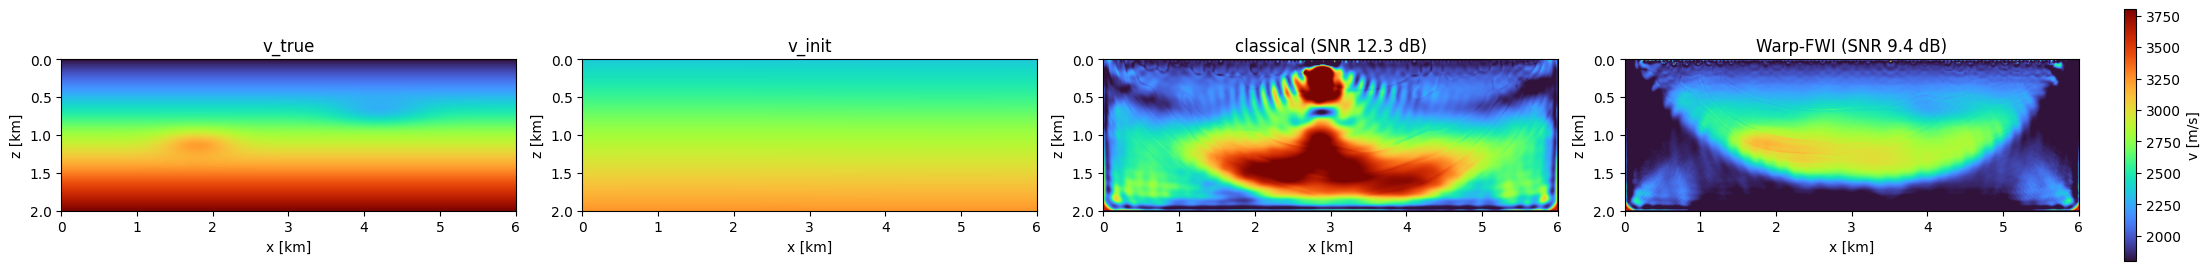

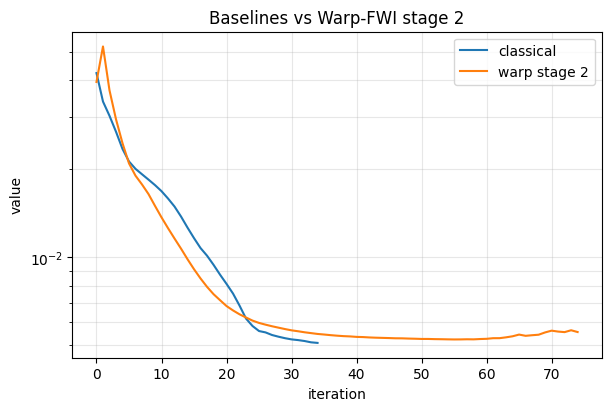

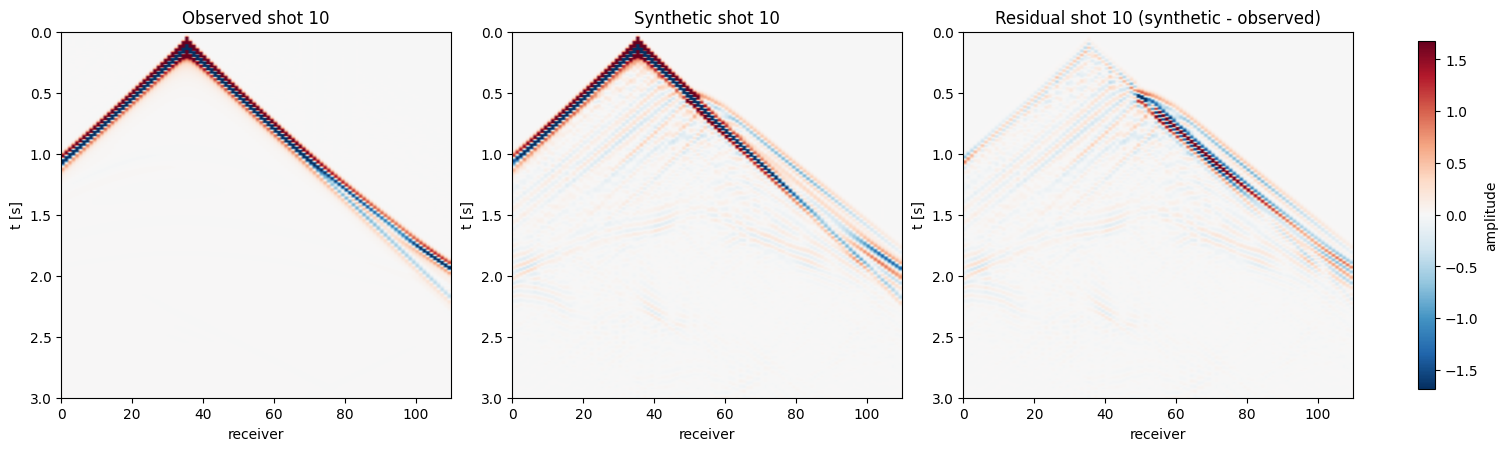

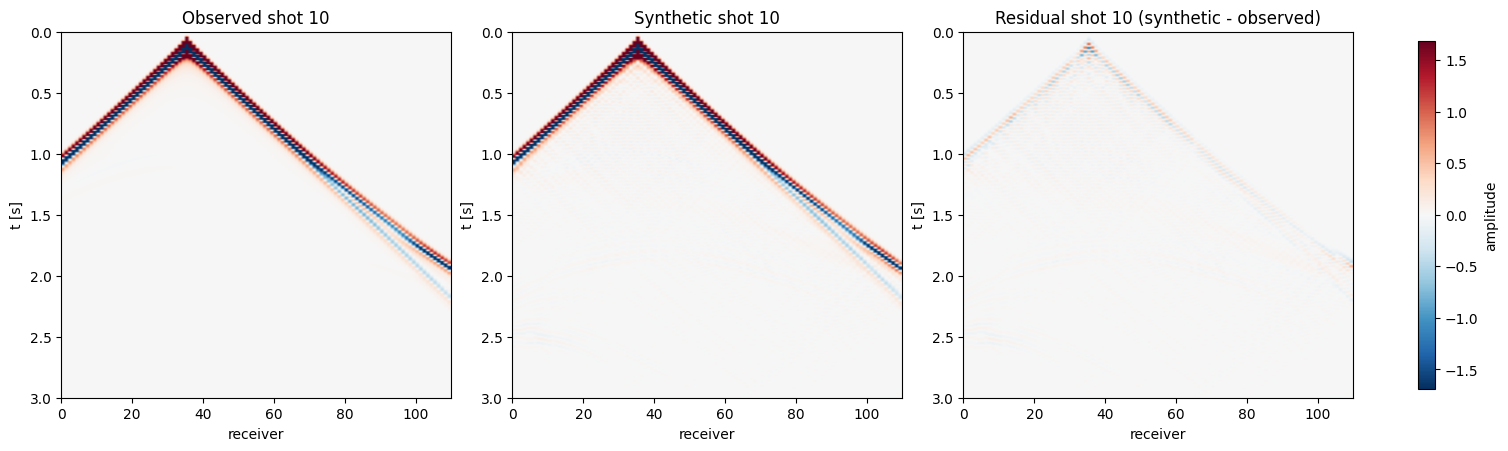

In [15]:
fig = plot_velocity_panels(
    [v_true, v_init, v_c, v_w],
    ['v_true', 'v_init', f'classical (SNR {snr_db(v_c, v_true):.1f} dB)',
     f'Warp-FWI (SNR {snr_db(v_w, v_true):.1f} dB)'],
    dx=cfg.data.dx,
    vmin=vmin,
    vmax=vmax,
    shared_colorbar=velocity_shared_colorbar,
)
plt.show()

fig = plot_loss_curves(
    {'classical': log_c['loss'], 'warp stage 2': log_s2['loss']},
    title='Baselines vs Warp-FWI stage 2',
)
plt.show()

fig = plot_shot_triplet(
    d_obs[shot_plot_idx],
    d_syn_classical,
    dt=acq.dt,
    shot_idx=shot_plot_idx,
    shared_clim=gather_shared_clim,
    robust_pct=gather_robust_pct,
)
plt.show()

d_syn_warp = simulate_batch(v_w, acq, shot_idx_t, cfg.modeling, device=device)[0]

fig = plot_shot_triplet(
    d_obs[shot_plot_idx],
    d_syn_warp,
    dt=acq.dt,
    shot_idx=shot_plot_idx,
    shared_clim=gather_shared_clim,
    robust_pct=gather_robust_pct,
)
plt.show()


## 8.5 Switch to classical FWI to fit the data

[classical:preprocess] bandpass enabled f=[4, 7] Hz order=4; time_axis=-1
[classical:preprocess] filtering mode: observed receiver data filtered=True  source wavelet filtered before propagation=True  synthetic receiver data filtered after propagation=False
[classical:init] optimizer=adam lr=0.08  v_init=[2356.7, 3243.9]  near_bounds=(0.000, 0.000)  exact_bounds=(0.000, 0.000)  phi0=[-1.13, -0.01]  |phi0|>(20,40,60)=(0.000, 0.000, 0.000)  recon_err(max,mean)=(1.736e+03, 6.666e+02)
[classical:first-batch:pre-step]  phi=[-7.10, 0.52]  v=[1502.9, 3692.0]  near_bounds=(0.008, 0.000)  |grad|=3.490e-05
[classical:first-batch:post-step]  phi=[-7.16, 0.53]  v=[1502.7, 3705.4]  near_bounds=(0.008, 0.000)
[classical] iter 1/35  loss=4.0512e-03  resid=6.365e-02  |grad|=4.053e-04  phi=[-7.40, 0.61]  v=[1502.1, 3764.8]  near_bounds=(0.008, 0.000)
[classical] iter 2/35  loss=3.7105e-03  resid=6.091e-02  |grad|=2.188e-04  phi=[-7.67, 0.60]  v=[1501.6, 3759.0]  near_bounds=(0.008, 0.000)
[classical] it

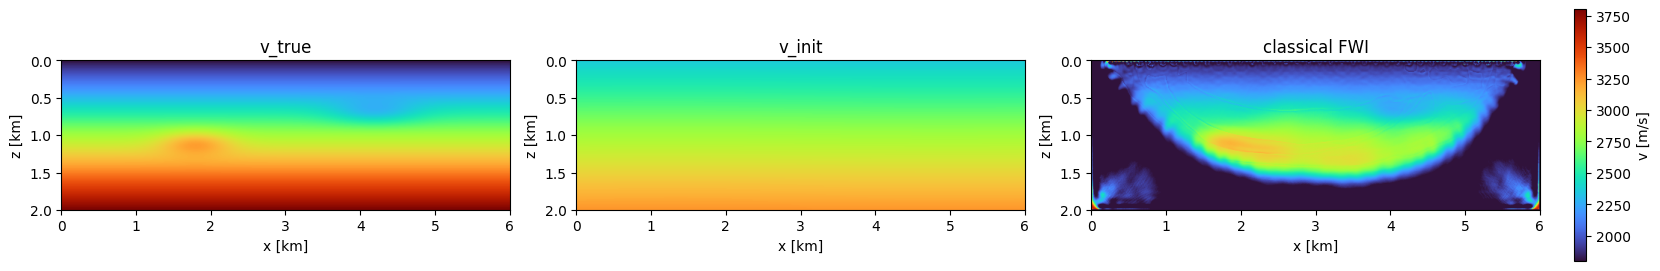

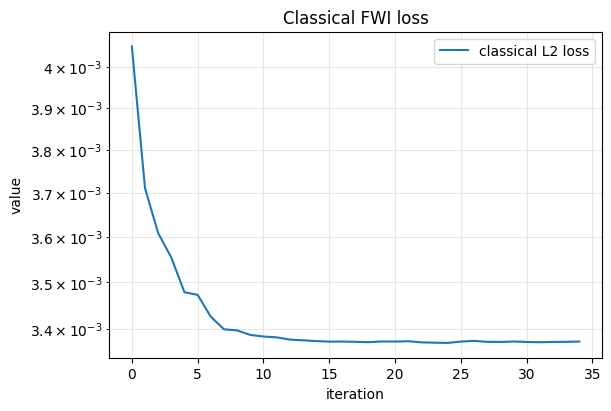

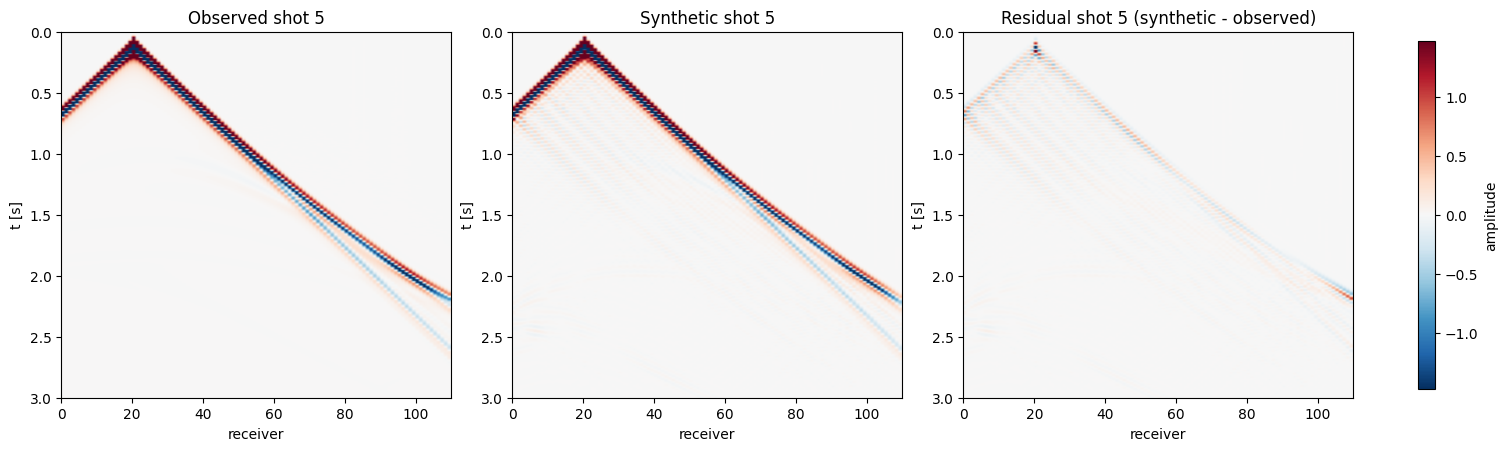

In [20]:

log_d = run_classical_fwi_loop(vp_warp, acq, d_obs, cfg.classical, device=device, log=print)
v_cw = vp_warp.v().detach()
print(f'classical: SNR={snr_db(v_c, v_true):.2f} dB, SSIM={ssim(v_cw, v_true):.3f}')

fig = plot_velocity_panels(
    [v_true, v_init, v_cw],
    ['v_true', 'v_init', 'classical FWI'],
    dx=cfg.data.dx,
    vmin=vmin,
    vmax=vmax,
    shared_colorbar=velocity_shared_colorbar,
)
plt.show()

fig = plot_loss_curves({'classical L2 loss': log_d['loss']}, title='Classical FWI loss')
plt.show()

d_syn_warp_classical = simulate_batch(v_cw, acq, shot_idx_t, cfg.modeling, device=device)[0]

fig = plot_shot_triplet(
    d_obs[shot_plot_idx],
    d_syn_warp_classical,
    dt=acq.dt,
    shot_idx=shot_plot_idx,
    shared_clim=gather_shared_clim,
    robust_pct=gather_robust_pct,
)
plt.show()

## 9. Hybrid envelope-theta / L2-velocity Warp-FWI

Run a fresh Warp-FWI experiment using envelope loss for the warp/alignment branch and L2 loss for the velocity branch. With `stage2_routing='auto'`, this should select the dual-gradient-routing path.


In [ ]:
hybrid_cfg = warpfwi_loss_configs['hybrid_envelope_theta_l2_v']
print('hybrid config:', hybrid_cfg)

vp_warp_hybrid = BoundedVelocity.from_velocity(
    v_init, cfg.data.v_min, cfg.data.v_max
).to(device)
inrs_hybrid = build_per_shot_inrs(acq.n_shots, cfg.inr, device=device)

log_s1_hybrid = pretrain_warp(
    vp_warp_hybrid, inrs_hybrid, acq, d_obs, hybrid_cfg,
    warp_cfg_T_max=T_max,
    warp_cfg_alpha=cfg.warp.alpha_smooth,
    warp_cfg_beta=cfg.warp.beta_gain,
    warp_cfg_offset_smooth=cfg.warp.offset_smooth,
    device=device, log=print,
)

log_s2_hybrid = run_warp_fwi(
    vp_warp_hybrid, inrs_hybrid, acq, d_obs, hybrid_cfg,
    warp_cfg_T_max=T_max,
    warp_cfg_alpha=cfg.warp.alpha_smooth,
    warp_cfg_beta=cfg.warp.beta_gain,
    warp_cfg_offset_smooth=cfg.warp.offset_smooth,
    warp_cfg_lambda_0=cfg.warp.lambda_0,
    warp_cfg_lambda_final=cfg.warp.lambda_final,
    warp_cfg_schedule=cfg.warp.schedule,
    device=device, log=print,
)

v_w_hybrid = vp_warp_hybrid.v().detach()
print('hybrid routing:', log_s2_hybrid['stage2_routing_mode'])
print('hybrid misfits:', log_s2_hybrid['stage2_theta_misfit_name'], log_s2_hybrid['stage2_v_misfit_name'])
print(f"Original L2 Warp-FWI: SNR={snr_db(v_w, v_true):.2f} dB, SSIM={ssim(v_w, v_true):.3f}")
print(f"Hybrid routed Warp-FWI: SNR={snr_db(v_w_hybrid, v_true):.2f} dB, SSIM={ssim(v_w_hybrid, v_true):.3f}")

fig = plot_velocity_panels(
    [v_true, v_init, v_w, v_w_hybrid],
    [
        'v_true',
        'v_init',
        f"original L2 (SNR {snr_db(v_w, v_true):.1f} dB)",
        f"hybrid routed (SNR {snr_db(v_w_hybrid, v_true):.1f} dB)",
    ],
    dx=cfg.data.dx,
    vmin=vmin,
    vmax=vmax,
    shared_colorbar=velocity_shared_colorbar,
)
plt.show()

fig = plot_loss_curves(
    {
        'original L2 total': log_s2['loss'],
        'hybrid total': log_s2_hybrid['loss'],
        'hybrid theta data': log_s2_hybrid['stage2_theta_data_term'],
        'hybrid v data': log_s2_hybrid['stage2_v_data_term'],
    },
    title='Original L2 vs hybrid routed Warp-FWI losses',
)
plt.show()

d_syn_hybrid = simulate_batch(v_w_hybrid, acq, shot_idx_t, cfg.modeling, device=device)[0]
fig = plot_shot_triplet(
    d_obs[shot_plot_idx],
    d_syn_hybrid,
    dt=acq.dt,
    shot_idx=shot_plot_idx,
    shared_clim=gather_shared_clim,
    robust_pct=gather_robust_pct,
)
plt.show()


## 10. Monotone NTW-inspired tracewise warp-FWI

This path is separate from the local-shift warp. It learns a per-shot monotone `psi_r(t)` by predicting raw positive-increment logits `a_raw(r, n)`, normalizing the increments, and sampling the synthetic gather at `psi_r(t)`. Stage 1 performs its own low-to-high data-frequency annealing inside the loss; no notebook-side filtering is needed.


In [ ]:
cfg.method = 'monotone_ntw'
monotone_cfg = cfg.monotone_ntw
print('method:', cfg.method)
print('monotone config:', monotone_cfg)

vp_mono = BoundedVelocity.from_velocity(v_init, cfg.data.v_min, cfg.data.v_max).to(device)
inrs_mono = build_per_shot_monotone_inrs(acq.n_shots, monotone_cfg.model, device=device)

log_s1_mono = pretrain_monotone_warp(
    vp_mono, inrs_mono, acq, d_obs, monotone_cfg, device=device, log=print,
)

grid_inc_mono = normalized_increment_grid(acq.n_receivers, acq.nt, device=device)
shot_idx_t = torch.tensor([shot_plot_idx], device=device)
with torch.no_grad():
    syn_s1_mono = simulate_batch(vp_mono.v(), acq, shot_idx_t, cfg.modeling, device=device)[0]
    mono_s1 = apply_monotone_warp(
        syn_s1_mono, inrs_mono[shot_plot_idx], grid_inc_mono,
        dt=acq.dt, increment_eps=monotone_cfg.model.increment_eps,
    )
    warped_s1_mono = mono_s1.warped
    psi_s1_mono = mono_s1.reconstruction.psi
    tau_s1_mono = mono_s1.reconstruction.tau

fig = plot_stage1_shot_comparison(
    d_obs[shot_plot_idx], syn_s1_mono, warped_s1_mono,
    dt=acq.dt, shot_idx=shot_plot_idx,
    shared_clim=gather_shared_clim, robust_pct=gather_robust_pct,
)
plt.show()

fig = plot_warp_field(tau_s1_mono, dt=acq.dt, title='monotone NTW tau = psi - t after stage 1')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for losses in log_s1_mono['loss_per_shot']:
    axes[0].semilogy(losses, alpha=0.35)
axes[0].set_title('monotone stage 1 loss per shot')
axes[0].set_xlabel('iteration')
axes[0].set_ylabel('loss')
axes[1].plot(log_s1_mono['cutoff_per_shot'][shot_plot_idx])
axes[1].set_title('internal cutoff schedule')
axes[1].set_xlabel('iteration')
axes[1].set_ylabel('Hz')
plt.show()

rec_idx = [0, acq.n_receivers // 2, acq.n_receivers - 1]
t_axis = torch.arange(acq.nt, device=device, dtype=psi_s1_mono.dtype) * acq.dt
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.plot(t_axis.cpu(), t_axis.cpu(), color='k', linewidth=1.0, label='identity')
for r_idx in rec_idx:
    ax.plot(t_axis.cpu(), psi_s1_mono[r_idx].detach().cpu(), label=f'r={r_idx}')
ax.set_title('selected monotone psi curves')
ax.set_xlabel('t [s]')
ax.set_ylabel('psi(t) [s]')
ax.legend()
plt.show()

last_diag = log_s1_mono['diagnostics_per_shot'][shot_plot_idx][-1]
print('stage 1 final diagnostics for plotted shot:')
for key in sorted(last_diag):
    print(f'  {key}: {last_diag[key]:.4e}')


In [ ]:
if monotone_cfg.run_stage2:
    log_s2_mono = run_monotone_warp_fwi(
        vp_mono, inrs_mono, acq, d_obs, monotone_cfg, device=device, log=print,
    )
    v_mono = vp_mono.v().detach()
    print(f'Monotone NTW Stage 2: SNR={snr_db(v_mono, v_true):.2f} dB, SSIM={ssim(v_mono, v_true):.3f}')

    fig = plot_velocity_panels(
        [v_true, v_init, v_w, v_mono],
        ['v_true', 'v_init', f'local-shift (SNR {snr_db(v_w, v_true):.1f} dB)',
         f'monotone_ntw (SNR {snr_db(v_mono, v_true):.1f} dB)'],
        dx=cfg.data.dx, vmin=vmin, vmax=vmax,
        shared_colorbar=velocity_shared_colorbar,
    )
    plt.show()

    fig = plot_loss_curves(
        {
            'monotone total': log_s2_mono['loss'],
            'theta data': log_s2_mono['theta_data'],
            'velocity data': log_s2_mono['v_data'],
            'regularizer': log_s2_mono['reg'],
        },
        title='monotone NTW stage 2 losses',
    )
    plt.show()
else:
    log_s2_mono = None
    print('monotone Stage 2 skipped; set cfg.monotone_ntw.run_stage2=True to run it.')
